<a href="https://colab.research.google.com/github/N3M3515069/deep-learning-fundamentals/blob/main/Vanilla_NN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

try:
  from torchmetrics import Accuracy
except:
  !pip install torchmetrics
  from torchmetrics import Accuracy

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

X = torch.from_numpy(X).float() / 255.0
y = torch.from_numpy(y.astype(np.int64))

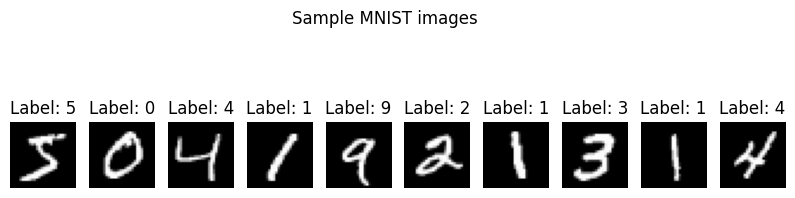

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i].item()}")
    ax.axis('off')
plt.suptitle("Sample MNIST images")
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [6]:
class MnistNN(nn.Module):
  def __init__(self,input, hidden, output):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Linear(in_features= input, out_features= hidden),
        nn.ReLU(),
        nn.Linear(in_features= hidden, out_features= hidden),
        nn.ReLU(),
        nn.Linear(in_features= hidden, out_features= output)
        )

  def forward(self, x):
    return self.layer_stack(x)

model = MnistNN(784, 64, 10).to(device)

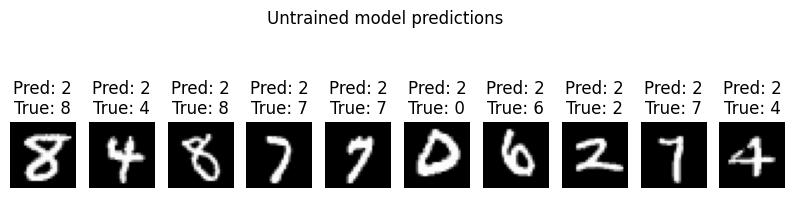

In [7]:
model.eval()
with torch.inference_mode():
    untrained_logits = model(X_test)
    untrained_preds = torch.softmax(untrained_logits, dim=1).argmax(dim=1)

fig, axes = plt.subplots(1, 10, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].cpu().reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {untrained_preds[i].item()}\nTrue: {y_test[i].item()}")
    ax.axis('off')
plt.suptitle("Untrained model predictions")
plt.show()

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
acc = Accuracy(task= 'multiclass', num_classes= 10).to(device)

In [9]:
torch.manual_seed(42)
epochs = 300

for epoch in range(epochs):
  model.train()

  train_logits = model(X_train)
  pred_labels = torch.softmax(train_logits, dim=1).argmax(dim=1)

  train_loss = loss_fn(train_logits, y_train)
  training_acc = acc(pred_labels, y_train)
  acc.reset()

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():

    test_logits = model(X_test)
    test_labels = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc(test_labels, y_test)
    acc.reset()

  if epoch % 50 == 0:
    print(f"epoch: {epoch} | train_loss: {train_loss:.2f} | training_acc: {training_acc:.2f}| test_loss: {test_loss:.2f} | test_acc: {test_acc:.2f}")

epoch: 0 | train_loss: 2.30 | training_acc: 0.10| test_loss: 2.28 | test_acc: 0.15
epoch: 50 | train_loss: 0.49 | training_acc: 0.87| test_loss: 0.48 | test_acc: 0.87
epoch: 100 | train_loss: 0.29 | training_acc: 0.92| test_loss: 0.30 | test_acc: 0.92
epoch: 150 | train_loss: 0.23 | training_acc: 0.93| test_loss: 0.25 | test_acc: 0.93
epoch: 200 | train_loss: 0.19 | training_acc: 0.95| test_loss: 0.21 | test_acc: 0.94
epoch: 250 | train_loss: 0.15 | training_acc: 0.96| test_loss: 0.18 | test_acc: 0.95


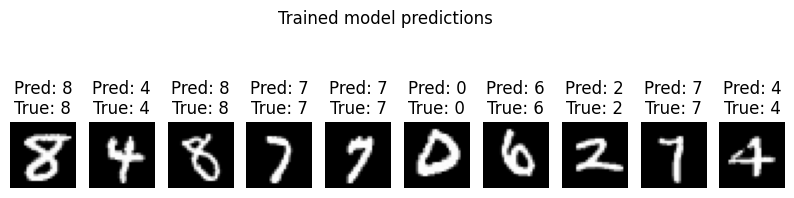

In [10]:
fig, axes = plt.subplots(1, 10, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].cpu().reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {test_labels[i].item()}\nTrue: {y_test[i].item()}")
    ax.axis('off')
plt.suptitle("Trained model predictions")
plt.show()